In [ ]:
!pip -q install qiskit
!pip -q install qiskit-ibm-runtime
!pip -q install qiskit_aer
!pip -q install qiskit[visualization]
!pip -q install pylatexenc
!pip -1 install cirq
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile
from math import pi, sqrt
from qiskit.visualization import plot_bloch_multivector, plot_histogram
import matplotlib.pyplot as plt
from IPython.display import display



Usage:   
  pip3 <command> [options]

no such option: -1


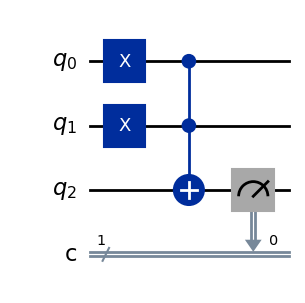


NOR Truth Table:
A=0, B=0 -> NOR=1
A=0, B=1 -> NOR=0
A=1, B=0 -> NOR=0
A=1, B=1 -> NOR=0


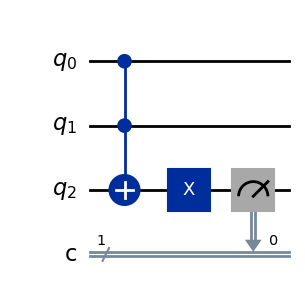


NAND Truth Table:
A=0, B=0 -> NAND=1
A=0, B=1 -> NAND=1
A=1, B=0 -> NAND=1
A=1, B=1 -> NAND=0


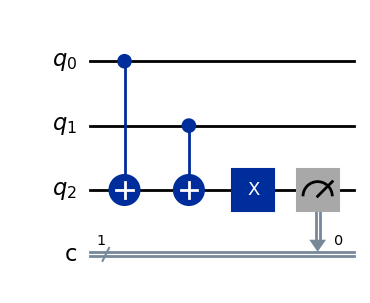


XNOR Truth Table:
A=0, B=0 -> XNOR=1
A=0, B=1 -> XNOR=0
A=1, B=0 -> XNOR=0
A=1, B=1 -> XNOR=1


In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

def nor_circuit():
    qc = QuantumCircuit(3, 1)
    qc.x(0); qc.x(1)        # invert inputs
    qc.ccx(0, 1, 2)         # (NOT A) AND (NOT B)
    qc.measure(2, 0)
    return qc

def nand_circuit():
    qc = QuantumCircuit(3, 1)
    qc.ccx(0, 1, 2)         # A AND B
    qc.x(2)                 # NOT of result
    qc.measure(2, 0)
    return qc

def xnor_circuit():
    qc = QuantumCircuit(3, 1)
    qc.cx(0, 2)             # XOR step 1
    qc.cx(1, 2)             # XOR step 2
    qc.x(2)                 # NOT XOR = XNOR
    qc.measure(2, 0)
    return qc



sim = AerSimulator()

def simulate_truth_table(gate_func, name):
    print(f"\n{name} Truth Table:")
    for a in [0,1]:
        for b in [0,1]:
            qc = QuantumCircuit(3,1)
            if a: qc.x(0)
            if b: qc.x(1)
            base = gate_func()
            qc.compose(base, inplace=True)
            tqc = transpile(qc, sim)
            result = sim.run(tqc, shots=1024).result()
            counts = result.get_counts()
            out = max(counts, key=counts.get)
            print(f"A={a}, B={b} -> {name}={out}")

display(nor_circuit().draw("mpl"))
simulate_truth_table(nor_circuit, "NOR")

display(nand_circuit().draw("mpl"))
simulate_truth_table(nand_circuit, "NAND")

display(xnor_circuit().draw("mpl"))
simulate_truth_table(xnor_circuit, "XNOR")


In [ ]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

def XOR(qc, a, b, output):
    qc.cx(a, output)
    qc.cx(b, output)

def diffuser(nqubits):
    qc = QuantumCircuit(nqubits)
    for qubit in range(nqubits):
        qc.h(qubit)
    for qubit in range(nqubits):
        qc.x(qubit)
    qc.h(nqubits-1)
    qc.mcx(list(range(nqubits-1)), nqubits-1)
    qc.h(nqubits-1)
    for qubit in range(nqubits):
        qc.x(qubit)
    for qubit in range(nqubits):
        qc.h(qubit)
    return qc.to_gate(label="U_s")

clause_list = [[0,1],[0,2],[1,3],[2,3]]

def sudoku_oracle(qc, clause_list, clause_qubits, output_qubit):
    for i, clause in enumerate(clause_list):
        XOR(qc, clause[0], clause[1], clause_qubits[i])
    qc.mcx(clause_qubits, output_qubit[0])
    for i, clause in enumerate(clause_list):
        XOR(qc, clause[0], clause[1], clause_qubits[i])

var_qubits = QuantumRegister(4, name='v')
clause_qubits = QuantumRegister(4, name='c')
output_qubit = QuantumRegister(1, name='out')
cbits = ClassicalRegister(4, name='cbits')
qc = QuantumCircuit(var_qubits, clause_qubits, output_qubit, cbits)

qc.initialize([1/np.sqrt(2), -1/np.sqrt(2)], output_qubit)
qc.h(var_qubits)
qc.barrier()

for _ in range(2):
    sudoku_oracle(qc, clause_list, clause_qubits, output_qubit)
    qc.append(diffuser(4), var_qubits)
    qc.barrier()

qc.measure(var_qubits, cbits)

# Display the circuit
fig = qc.draw(output='mpl')
plt.show(fig)

# Run on AerSimulator and show histogram
qasm_simulator = AerSimulator()
transpiled_qc = transpile(qc, qasm_simulator)
result = qasm_simulator.run(transpiled_qc).result()

fig2 = plot_histogram(result.get_counts())
plt.show(fig2)


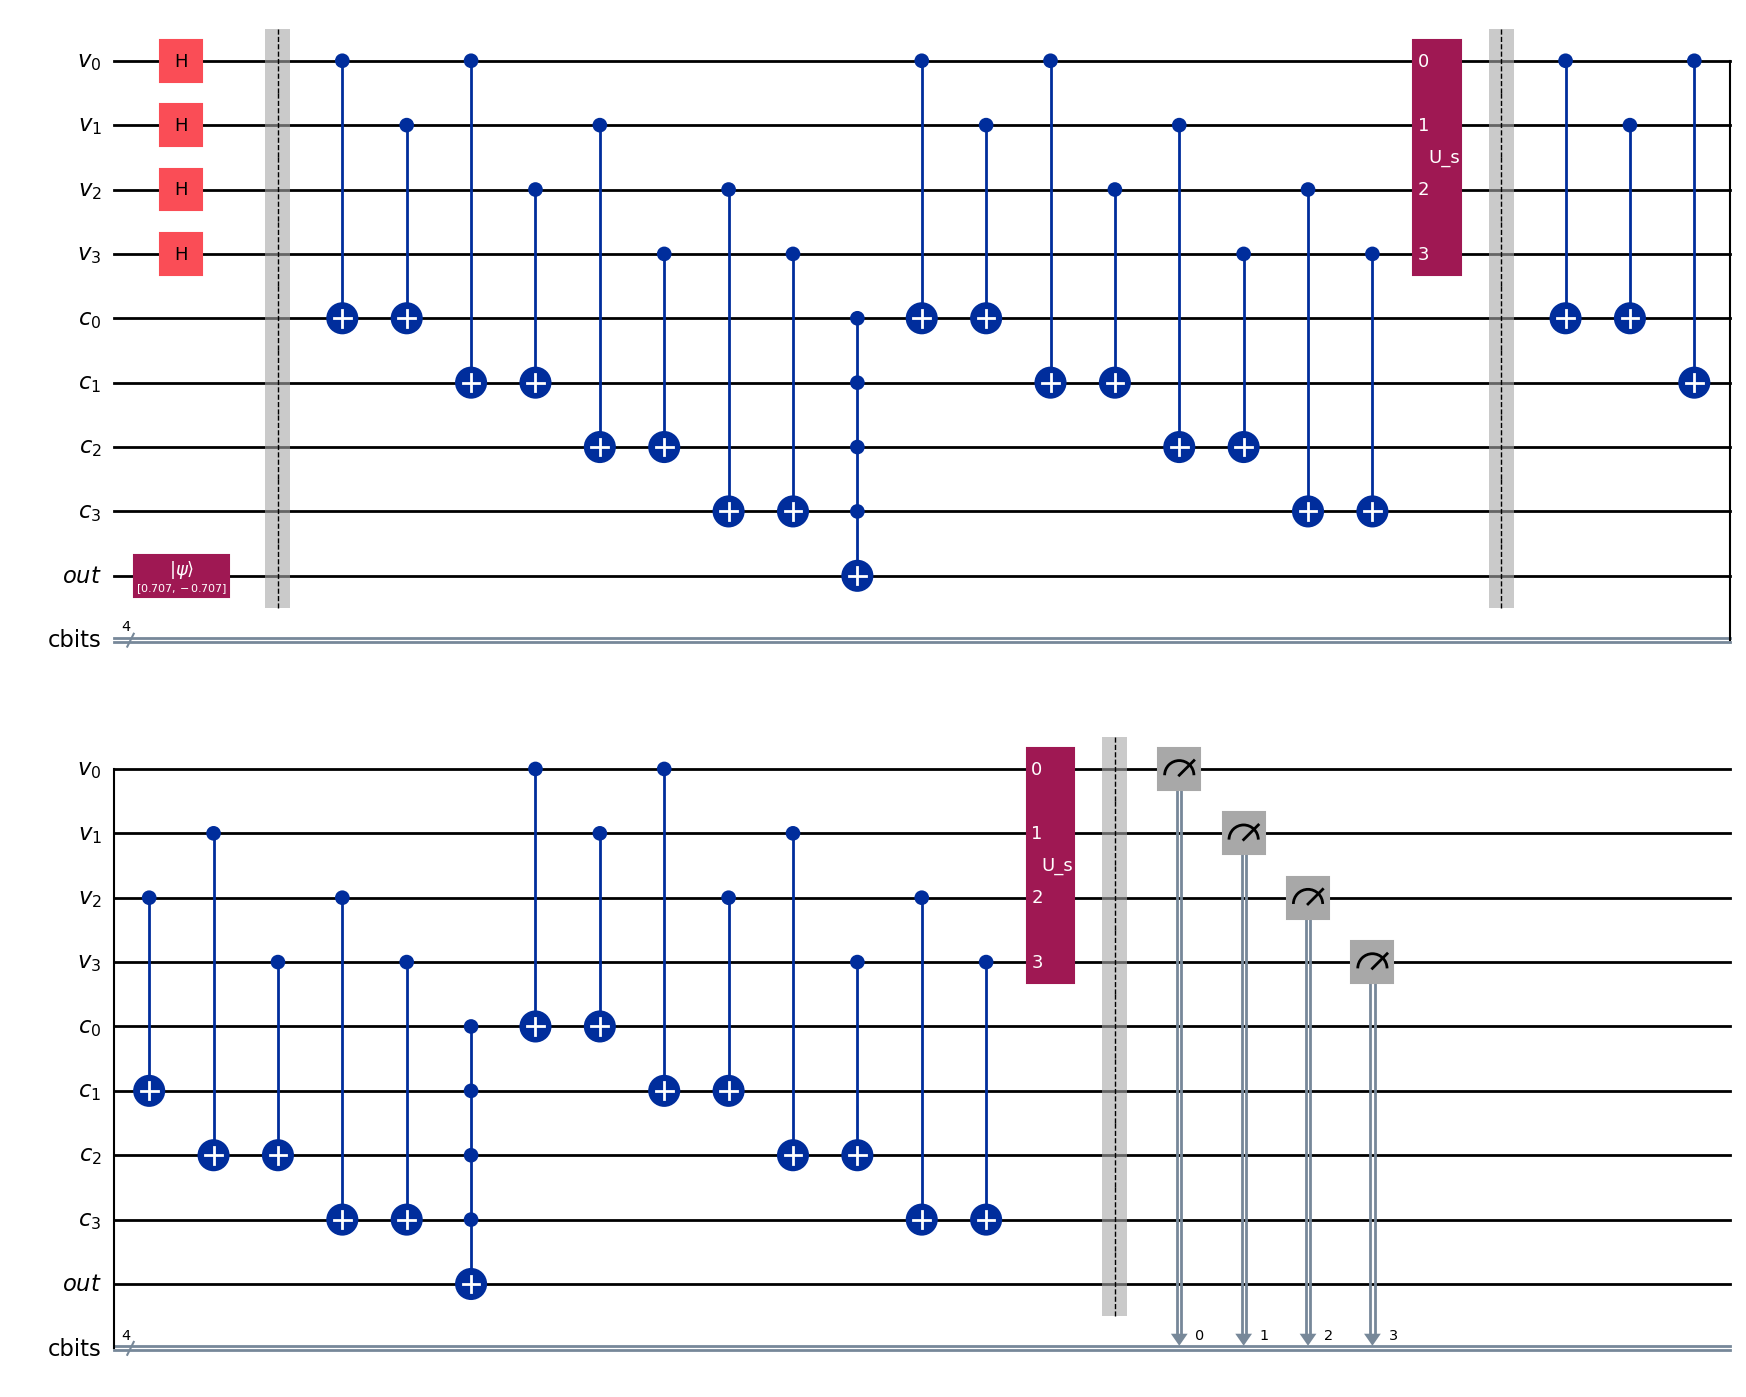

In [ ]:
fig

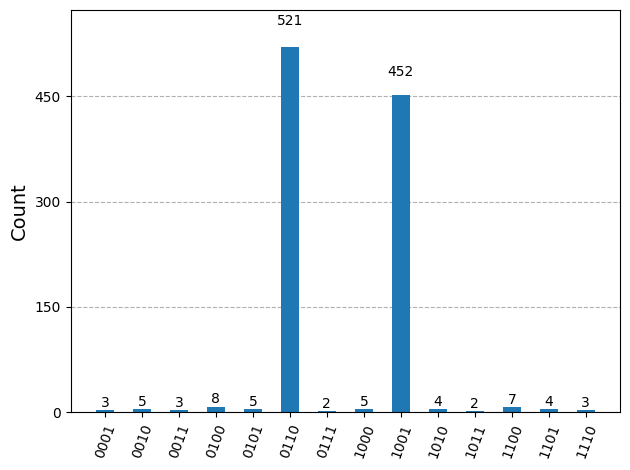

In [ ]:
fig2

=== Grover's Algorithm for 4x4 Sudoku Solving ===

Classical Solution:
┌─────┬─────┐
│ 1  3 │ 2  4 │
│ 4  2 │ 3  1 │
├─────┼─────┤
│ 2  1 │ 4  3 │
│ 3  4 │ 1  2 │
└─────┴─────┘

Quantum Solution using Grover's Algorithm:
4x4 Sudoku Puzzle:
┌─────┬─────┐
│ 1  . │ .  4 │
│ .  2 │ .  . │
├─────┼─────┤
│ .  . │ 4  . │
│ 3  . │ .  2 │
└─────┴─────┘

Using 8 qubits
Total states: 256
Optimal iterations: 10

Quantum Circuit Depth: 83
Number of Operations: 396

Measurement Results:
State |10100110⟩: 25 counts (0.024 probability)
State |00001110⟩: 24 counts (0.023 probability)
State |00111110⟩: 23 counts (0.022 probability)
State |11000110⟩: 23 counts (0.022 probability)
State |00010110⟩: 23 counts (0.022 probability)


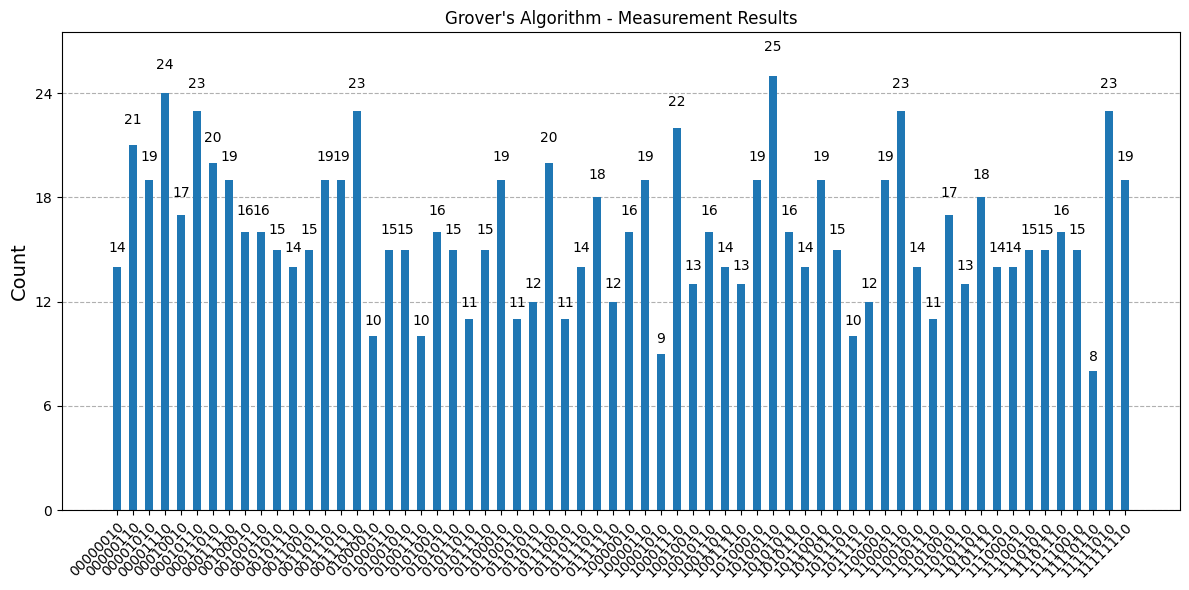


Quantum Circuit Structure (mpl diagram):


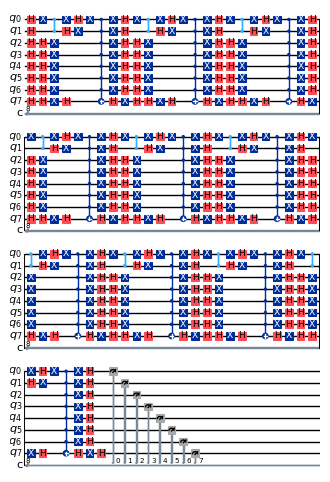

In [ ]:
import math
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

class GroverSudokuSolver:
    def __init__(self):
        self.simulator = AerSimulator()

    def create_4x4_sudoku_oracle(self, puzzle):
        """
        Creates an oracle for 4x4 Sudoku puzzle.
        Simplified version for demonstration.
        """
        n_qubits = 8  # Simplified version for demonstration
        qreg = QuantumRegister(n_qubits, 'q')
        oracle = QuantumCircuit(qreg)
        oracle.x(qreg[0])  # Example constraint
        oracle.cz(qreg[0], qreg[1])  # Example interaction
        oracle.x(qreg[0])  # Uncompute
        return oracle

    def create_diffusion_operator(self, n_qubits):
        """Creates the diffusion operator (amplitude amplification about average)"""
        qreg = QuantumRegister(n_qubits, 'q')
        diffusion = QuantumCircuit(qreg)
        # Apply Hadamard to all qubits
        for i in range(n_qubits):
            diffusion.h(qreg[i])
        # Apply X gates to all qubits
        for i in range(n_qubits):
            diffusion.x(qreg[i])
        # Multi-controlled Z gate (phase flip for |00...0⟩ state)
        if n_qubits > 1:
            diffusion.h(qreg[n_qubits-1])
            diffusion.mcx(list(range(n_qubits-1)), qreg[n_qubits-1])
            diffusion.h(qreg[n_qubits-1])
        # Apply X gates to all qubits (uncompute)
        for i in range(n_qubits):
            diffusion.x(qreg[i])
        # Apply Hadamard to all qubits (uncompute)
        for i in range(n_qubits):
            diffusion.h(qreg[i])
        return diffusion

    def solve_sudoku_simplified(self, puzzle):
        print("4x4 Sudoku Puzzle:")
        self.print_sudoku(puzzle)

        n_qubits = 8
        N = 2**n_qubits  # Total number of states
        M = 1  # Assume 1 solution for simplicity
        optimal_iterations = int(math.pi/4 * math.sqrt(N/M))
        iterations = min(optimal_iterations, 10)

        print(f"\nUsing {n_qubits} qubits")
        print(f"Total states: {N}")
        print(f"Optimal iterations: {iterations}")

        qreg = QuantumRegister(n_qubits, 'q')
        creg = ClassicalRegister(n_qubits, 'c')
        circuit = QuantumCircuit(qreg, creg)

        # Initialize superposition
        for i in range(n_qubits):
            circuit.h(qreg[i])

        # Apply Grover iterations
        oracle = self.create_4x4_sudoku_oracle(puzzle)
        diffusion = self.create_diffusion_operator(n_qubits)
        for iteration in range(iterations):
            circuit.compose(oracle, inplace=True)
            circuit.compose(diffusion, inplace=True)

        # Measure all qubits
        circuit.measure(qreg, creg)

        # Execute circuit
        transpiled_circuit = transpile(circuit, self.simulator)
        job = self.simulator.run(transpiled_circuit, shots=1024)
        result = job.result()
        counts = result.get_counts()
        return circuit, counts

    def print_sudoku(self, puzzle):
        """Print 4x4 Sudoku puzzle in a nice format"""
        print("┌─────┬─────┐")
        for i in range(4):
            if i == 2:
                print("├─────┼─────┤")
            row_str = "│"
            for j in range(4):
                if j == 2:
                    row_str += "│"
                if puzzle[i][j] == 0:
                    row_str += " . "
                else:
                    row_str += f" {puzzle[i][j]} "
            row_str += "│"
            print(row_str)
        print("└─────┴─────┘")

    def classical_sudoku_solver(self, puzzle):
        """Classical solver for comparison"""
        def is_valid(puzzle, row, col, num):
            for j in range(4):
                if puzzle[row][j] == num:
                    return False
            for i in range(4):
                if puzzle[i][col] == num:
                    return False
            box_row, box_col = 2 * (row // 2), 2 * (col // 2)
            for i in range(box_row, box_row + 2):
                for j in range(box_col, box_col + 2):
                    if puzzle[i][j] == num:
                        return False
            return True

        def solve(puzzle):
            for i in range(4):
                for j in range(4):
                    if puzzle[i][j] == 0:
                        for num in range(1, 5):
                            if is_valid(puzzle, i, j, num):
                                puzzle[i][j] = num
                                if solve(puzzle):
                                    return True
                                puzzle[i][j] = 0
                        return False
            return True

        solution = [row[:] for row in puzzle]
        if solve(solution):
            return solution
        return None


# Example usage
def main():
    solver = GroverSudokuSolver()
    puzzle = [
        [1, 0, 0, 4],
        [0, 2, 0, 0],
        [0, 0, 4, 0],
        [3, 0, 0, 2]
    ]

    print("=== Grover's Algorithm for 4x4 Sudoku Solving ===\n")
    print("Classical Solution:")
    classical_solution = solver.classical_sudoku_solver(puzzle)
    if classical_solution:
        solver.print_sudoku(classical_solution)
    else:
        print("No solution found classically")

    print("\n" + "="*50)
    print("Quantum Solution using Grover's Algorithm:")
    print("="*50)

    quantum_circuit, measurement_counts = solver.solve_sudoku_simplified(puzzle)

    print(f"\nQuantum Circuit Depth: {quantum_circuit.depth()}")
    print(f"Number of Operations: {len(quantum_circuit.data)}")
    print("\nMeasurement Results:")
    sorted_counts = sorted(measurement_counts.items(), key=lambda x: x[1], reverse=True)
    for state, count in sorted_counts[:5]:
        probability = count / 1024
        print(f"State |{state}⟩: {count} counts ({probability:.3f} probability)")

    if measurement_counts:
        fig, ax = plt.subplots(figsize=(12, 6))
        plot_histogram(measurement_counts, ax=ax)
        plt.title("Grover's Algorithm - Measurement Results")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # Display quantum circuit using mpl
    print(f"\nQuantum Circuit Structure (mpl diagram):")
    fig, ax = plt.subplots(figsize=(12, 6))
    quantum_circuit.draw(output='mpl', ax=ax)
    plt.show()


if __name__ == "__main__":
    main()
